# CCA Cross-Session Analysis

Batch-process CCA across all qualifying sessions, then aggregate and visualize.

**Prerequisites:** This notebook is self-contained. It includes all helper functions
needed to run `run_session_cca()` on each session and save per-session parquet files.
Cross-session averages and heatmaps are generated from the saved results.

Single-session exploratory analysis is in `CCA_by_claude.ipynb`.

## 1. Imports

In [1]:
import pathlib
import time
import traceback
from itertools import combinations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA

import npc_lims
from dynamic_routing_analysis import spike_utils
from dynamic_routing_analysis import data_utils

%load_ext autoreload
%autoreload 2

## 2. Configuration

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────
session_table_path = r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.272.parquet"
savepath = r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CCA results"

output_dir = pathlib.Path(savepath)
output_dir.mkdir(parents=True, exist_ok=True)

# ── CCA pipeline parameters ────────────────────────────────────────────────────
MIN_UNITS      = 5      # minimum units per structure
VAR_THRESH     = 0.80   # PCA variance threshold
MAX_CCA_COMPS  = 10     # cap on CCA components per pair
N_BOOT         = 0      # bootstrap iterations (0 = skip for speed)

print(f"Output directory: {output_dir}")
print(f"Parameters: MIN_UNITS={MIN_UNITS}, VAR_THRESH={VAR_THRESH}, "
      f"MAX_CCA_COMPS={MAX_CCA_COMPS}, N_BOOT={N_BOOT}")

Output directory: \\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CCA results
Parameters: MIN_UNITS=5, VAR_THRESH=0.8, MAX_CCA_COMPS=10, N_BOOT=0


## 3. Helper Functions

All functions needed by `run_session_cca()`, copied from the single-session notebook.

In [3]:
def generate_DR_ITI(n_samples=None, is_templeton=False):
    """Generate inter-trial intervals matching the DynamicRouting task."""
    import random

    preStimFramesFixed = 90
    preStimFramesVariableMean = 60
    preStimFramesMax = 360
    responseWindow = [6, 60]
    postResponseWindowFrames = 180

    if is_templeton:
        preStimFramesVariableMean = 30
        preStimFramesMax = 240
        postResponseWindowFrames = 120

    if n_samples is not None:
        return [generate_DR_ITI(is_templeton=is_templeton) for _ in range(n_samples)]
    else:
        val = (preStimFramesFixed + random.expovariate(1 / preStimFramesVariableMean)
               if preStimFramesVariableMean > 1
               else preStimFramesFixed + preStimFramesVariableMean)
        trial_total_length = (
            int(min(val, preStimFramesMax)) + responseWindow[1] + postResponseWindowFrames
        ) / 60
        return trial_total_length


def pca_fit_keep(X, var_thresh=0.80):
    """Fit PCA and keep enough components to reach var_thresh."""
    pca_full = PCA().fit(X)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    n_keep = np.searchsorted(cumvar, var_thresh) + 1
    pca = PCA(n_components=n_keep).fit(X)
    return pca, n_keep, cumvar


def match_dims(X1_pca, X2_pca):
    """Match dimensions between two PCA-reduced datasets."""
    d = min(X1_pca.shape[1], X2_pca.shape[1])
    return X1_pca[:, :d], X2_pca[:, :d], d


def canonical_corrs(X_c, Y_c):
    """Calculate canonical correlations between paired canonical variables."""
    corrs = []
    for i in range(X_c.shape[1]):
        r = np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1]
        corrs.append(r)
    return np.array(corrs)


def run_cca(X1, X2, n_components=None):
    """Run CCA between two datasets."""
    d = min(X1.shape[1], X2.shape[1])
    if n_components is None:
        n_components = d
    n_components = min(n_components, d, X1.shape[0] - 1, X2.shape[0] - 1)
    if n_components < 1:
        raise ValueError("Not enough samples to fit CCA.")
    cca = CCA(n_components=n_components)
    cca.fit(X1, X2)
    X1_c, X2_c = cca.transform(X1, X2)
    return cca, X1_c, X2_c


def principal_angles(U, V):
    """Principal angles between two subspaces (U, V: d x k matrices). Returns radians."""
    Uo, _ = np.linalg.qr(U)
    Vo, _ = np.linalg.qr(V)
    s = np.linalg.svd(Uo.T @ Vo, compute_uv=False)
    s = np.clip(s, -1.0, 1.0)
    return np.arccos(s)


def bootstrap_corrs(X, Y, n_components, n_boot=1000):
    """Bootstrap canonical correlations within an epoch."""
    n_samples = X.shape[0]
    boot_corrs = np.zeros((n_boot, n_components))
    for b in range(n_boot):
        idx = np.random.choice(n_samples, n_samples, replace=True)
        cca, X_c, Y_c = run_cca(X[idx], Y[idx], n_components=n_components)
        boot_corrs[b] = canonical_corrs(X_c, Y_c)
    return boot_corrs


print("Helper functions defined.")

Helper functions defined.


In [4]:
def run_cca_pair(dA, dB, max_cca_comps=MAX_CCA_COMPS, n_boot=N_BOOT):
    """
    Run the full CCA pipeline for a single (struct_A, struct_B) pair.
    Returns a list of dicts, one per canonical component.
    """
    A_task_m,  B_task_m,  d_task  = match_dims(dA['task_pca'],  dB['task_pca'])
    A_spont_m, B_spont_m, d_spont = match_dims(dA['spont_pca'], dB['spont_pca'])

    k_task  = min(max_cca_comps, d_task,  A_task_m.shape[0]  - 1, B_task_m.shape[0]  - 1)
    k_spont = min(max_cca_comps, d_spont, A_spont_m.shape[0] - 1, B_spont_m.shape[0] - 1)
    k       = min(k_task, k_spont)

    if k < 1:
        return []

    try:
        cca_task,  A_task_c,  B_task_c  = run_cca(A_task_m,  B_task_m,  n_components=k)
        cca_spont, A_spont_c, B_spont_c = run_cca(A_spont_m, B_spont_m, n_components=k)
    except Exception:
        return []

    r_task  = canonical_corrs(A_task_c,  B_task_c)
    r_spont = canonical_corrs(A_spont_c, B_spont_c)

    A_task_in_spont, B_task_in_spont = cca_spont.transform(A_task_m[:, :d_spont], B_task_m[:, :d_spont])
    A_spont_in_task, B_spont_in_task = cca_task.transform(A_spont_m[:, :d_task],  B_spont_m[:, :d_task])
    r_task_in_spont  = canonical_corrs(A_task_in_spont,  B_task_in_spont)
    r_spont_in_task  = canonical_corrs(A_spont_in_task, B_spont_in_task)

    U_task_A  = cca_task.x_weights_[:, :k]
    U_spont_A = cca_spont.x_weights_[:, :k]
    U_task_B  = cca_task.y_weights_[:, :k]
    U_spont_B = cca_spont.y_weights_[:, :k]

    angles_A_deg = principal_angles(U_task_A, U_spont_A) * 180 / np.pi
    angles_B_deg = principal_angles(U_task_B, U_spont_B) * 180 / np.pi

    task_ci  = np.full((2, k), np.nan)
    spont_ci = np.full((2, k), np.nan)
    if n_boot > 0:
        boot_task  = bootstrap_corrs(A_task_m,  B_task_m,  n_components=k, n_boot=n_boot)
        boot_spont = bootstrap_corrs(A_spont_m, B_spont_m, n_components=k, n_boot=n_boot)
        task_ci  = np.percentile(boot_task,  [2.5, 97.5], axis=0)
        spont_ci = np.percentile(boot_spont, [2.5, 97.5], axis=0)

    records = []
    for i in range(k):
        records.append({
            'component'       : i + 1,
            'n_cca_comps'     : k,
            'r_task'          : r_task[i],
            'r_spont'         : r_spont[i],
            'r_task_in_spont' : r_task_in_spont[i],
            'r_spont_in_task' : r_spont_in_task[i],
            'r_task_ci_lo'    : task_ci[0, i],
            'r_task_ci_hi'    : task_ci[1, i],
            'r_spont_ci_lo'   : spont_ci[0, i],
            'r_spont_ci_hi'   : spont_ci[1, i],
            'angle_A_deg'     : angles_A_deg[i],
            'angle_B_deg'     : angles_B_deg[i],
            'n_pca_A'         : dA['n_pc'],
            'n_pca_B'         : dB['n_pc'],
            'n_units_A'       : dA['n_units'],
            'n_units_B'       : dB['n_units'],
            'n_task_trials'   : A_task_m.shape[0],
            'n_spont_trials'  : A_spont_m.shape[0],
        })
    return records


print("run_cca_pair() defined.")

run_cca_pair() defined.


## 4. Session List

In [5]:
session_table = pl.read_parquet(session_table_path)

dr_session_list = (
    session_table.filter(
        pl.col('is_production'),
        pl.col('is_annotated'),
        pl.col('issues') == [],
    )['session_id'].to_list()
)

print(f"Initial session list: {len(dr_session_list)} sessions")

Initial session list: 178 sessions


## 5. Batch Processing

Run all-pairs CCA for each session. Results are saved as parquet files;
sessions with existing output files are skipped automatically.

In [6]:
def run_session_cca(session_id, output_dir,
                    min_units=MIN_UNITS, var_thresh=VAR_THRESH,
                    max_cca_comps=MAX_CCA_COMPS, n_boot=N_BOOT,
                    time_before=0.5, time_after=0.01, binsize=0.5):
    """
    Run the full all-pairs CCA pipeline for one session and save results.

    Returns
    -------
    'saved'    - completed and files written
    'exists'   - output files already present (skipped)
    'no_spont' - no pre-task Spontaneous epoch or insufficient data (skipped)
    'error'    - unexpected exception (skipped)
    """
    component_path = output_dir / f'cca_components_{session_id}.parquet'
    summary_path   = output_dir / f'cca_summary_{session_id}.parquet'

    if component_path.exists() and summary_path.exists():
        return 'exists'

    try:
        # Load session data
        session_info = npc_lims.get_session_info(session_id)
        trials = data_utils.load_trials_or_units(session_info, 'trials', version='0.0.272')
        units  = data_utils.load_trials_or_units(session_info, 'units',  version='0.0.272')
        epochs = pd.read_parquet(
            npc_lims.get_cache_path(nwb_component='epochs', session_id=session_id, version='0.0.272')
        )

        # Check for pre-task Spontaneous epoch
        task_rows = epochs.query('script_name=="DynamicRouting1"')
        if len(task_rows) == 0:
            return 'no_spont'
        task_index = task_rows.index[0]
        spont_epochs = epochs.query('script_name=="Spontaneous" and id<@task_index')
        if len(spont_epochs) == 0:
            return 'no_spont'

        # Filter units
        units_filtered = units.query(
            'presence_ratio>=0.7 and '
            'isi_violations_ratio<=0.5 and '
            'amplitude_cutoff<=0.1 and '
            'activity_drift<=0.2 and '
            'firing_rate>=0.5 and '
            '~structure.isna() and ~location.isna()'
        ).sort_values(['electrode_group_name', 'peak_channel', 'unit_id'])

        if len(units_filtered) == 0:
            return 'no_spont'

        # Build task neural tensor
        trial_da = spike_utils.make_neuron_time_trials_tensor(
            units_filtered, trials, time_before, time_after, binsize
        )

        # Build spontaneous neural tensor
        import lazynwb
        nwb_path = 's3://aind-scratch-data/dynamic-routing/cache/nwb/v0.0.272/{sid}.nwb'
        rewards = lazynwb.get_df(
            nwb_path.format(sid=session_id),
            'processing/behavior/rewards',
            as_polars=False
        )

        spont_trials_dict = {'start_time': [], 'epoch_idx': [], 'epoch_name': [], 'is_rewarded': []}
        for rr, row in spont_epochs.iterrows():
            spont_start, spont_end = row['start_time'], row['stop_time']
            sampleITIs   = generate_DR_ITI(n_samples=1000, is_templeton=False)
            cum_ITIs     = np.cumsum(sampleITIs)
            valid_starts = spont_start + cum_ITIs[cum_ITIs + spont_start < spont_end]
            is_rew       = np.zeros(len(valid_starts), dtype=bool)

            reward_times = rewards.query(
                'timestamps>=@spont_start and timestamps<=@spont_end'
            )['timestamps'].to_numpy()
            if len(reward_times) > 0:
                for rt in reward_times:
                    keep = np.abs(valid_starts - rt) > 5.5
                    valid_starts, is_rew = valid_starts[keep], is_rew[keep]
                valid_starts = np.concatenate([valid_starts, reward_times])
                is_rew       = np.concatenate([is_rew, np.ones(len(reward_times), dtype=bool)])

            spont_trials_dict['start_time'].append(valid_starts)
            spont_trials_dict['epoch_idx'].append(np.repeat(rr, len(valid_starts)))
            spont_trials_dict['epoch_name'].append(np.repeat(row['script_name'], len(valid_starts)))
            spont_trials_dict['is_rewarded'].append(is_rew)

        for k in spont_trials_dict:
            spont_trials_dict[k] = np.concatenate(spont_trials_dict[k])
        spont_trials_df = (
            pd.DataFrame(spont_trials_dict)
            .sort_values('start_time')
            .reset_index(drop=True)
        )
        if len(spont_trials_df) == 0:
            return 'no_spont'

        spont_trial_da = spike_utils.make_neuron_time_trials_tensor(
            units_filtered, spont_trials_df, time_before, time_after, binsize,
            event_name='start_time'
        )

        # Per-structure PCA
        unit_counts = units_filtered.groupby('structure')['unit_id'].nunique()
        qualified_structures = sorted(unit_counts[unit_counts >= min_units].index.tolist())
        if len(qualified_structures) < 2:
            return 'no_spont'

        struct_data = {}
        for struct in qualified_structures:
            uid     = units_filtered[units_filtered['structure'] == struct]['unit_id'].unique()
            A_task  = trial_da.sel(unit_id=uid).data[:, 0, :].T
            A_spont = spont_trial_da.sel(unit_id=uid).data[:, 0, :].T
            A_pool  = np.vstack([A_task, A_spont])
            scaler  = StandardScaler().fit(A_pool)
            A_pool_z  = scaler.transform(A_pool)
            A_task_z  = A_pool_z[:A_task.shape[0]]
            A_spont_z = A_pool_z[A_task.shape[0]:]
            pca, n_pc, _ = pca_fit_keep(A_pool_z, var_thresh=var_thresh)
            struct_data[struct] = {
                'task_z': A_task_z,  'spont_z': A_spont_z,
                'pca': pca, 'n_pc': n_pc, 'n_units': len(uid),
                'task_pca': pca.transform(A_task_z),
                'spont_pca': pca.transform(A_spont_z),
            }

        # All-pairs CCA
        all_records = []
        for sA, sB in combinations(qualified_structures, 2):
            pair_records = run_cca_pair(struct_data[sA], struct_data[sB],
                                        max_cca_comps=max_cca_comps, n_boot=n_boot)
            for rec in pair_records:
                rec['struct_A'] = sA
                rec['struct_B'] = sB
            all_records.extend(pair_records)

        if len(all_records) == 0:
            return 'no_spont'

        # Build DataFrames
        col_order = [
            'session_id', 'struct_A', 'struct_B',
            'n_units_A', 'n_units_B', 'n_pca_A', 'n_pca_B',
            'n_task_trials', 'n_spont_trials', 'n_cca_comps', 'component',
            'r_task', 'r_task_ci_lo', 'r_task_ci_hi',
            'r_spont', 'r_spont_ci_lo', 'r_spont_ci_hi',
            'r_task_in_spont', 'r_spont_in_task',
            'angle_A_deg', 'angle_B_deg',
        ]
        cca_df = (
            pd.DataFrame(all_records)
            .assign(session_id=session_id)
            [col_order]
            .sort_values(['struct_A', 'struct_B', 'component'])
            .reset_index(drop=True)
        )
        sum_df = (
            cca_df
            .groupby(['session_id', 'struct_A', 'struct_B', 'n_units_A', 'n_units_B',
                      'n_pca_A', 'n_pca_B', 'n_task_trials', 'n_spont_trials', 'n_cca_comps'],
                     sort=False)
            .agg(
                mean_r_task          =('r_task',          'mean'),
                mean_r_spont         =('r_spont',         'mean'),
                mean_r_task_in_spont =('r_task_in_spont', 'mean'),
                mean_r_spont_in_task =('r_spont_in_task', 'mean'),
                mean_angle_A_deg     =('angle_A_deg',     'mean'),
                mean_angle_B_deg     =('angle_B_deg',     'mean'),
                r_task_comp1         =('r_task',          'first'),
                r_spont_comp1        =('r_spont',         'first'),
            )
            .assign(delta_r_task_spont=lambda d: d['mean_r_task'] - d['mean_r_spont'])
            .reset_index()
        )

        # Save
        cca_df.to_parquet(component_path, index=False)
        sum_df.to_parquet(summary_path,   index=False)
        return 'saved'

    except Exception:
        traceback.print_exc()
        return 'error'


print("run_session_cca() defined.")

run_session_cca() defined.


In [7]:
# ── Run over all sessions ──────────────────────────────────────────────────────
status_counts = {'saved': 0, 'exists': 0, 'no_spont': 0, 'error': 0}
t0 = time.time()

for s_idx, sid in enumerate(dr_session_list):
    status = run_session_cca(sid, output_dir)
    status_counts[status] += 1
    tag = {'saved': '\u2713', 'exists': '\u2013', 'no_spont': 'skip', 'error': 'ERR'}[status]
    print(f"[{s_idx+1:4d}/{len(dr_session_list)}]  {sid}  {tag}  "
          f"({time.time()-t0:.0f}s elapsed)")

print(f"\nDone.  {status_counts}")

620263_2022-07-26 cached trials loaded
620263_2022-07-26 cached units loaded
[   1/178]  620263_2022-07-26  skip  (28s elapsed)
620263_2022-07-27 cached trials loaded
620263_2022-07-27 cached units loaded
[   2/178]  620263_2022-07-27  skip  (34s elapsed)
620264_2022-08-02 cached trials loaded
620264_2022-08-02 cached units loaded
[   3/178]  620264_2022-08-02  skip  (43s elapsed)
626791_2022-08-15 cached trials loaded
626791_2022-08-15 cached units loaded
[   4/178]  626791_2022-08-15  skip  (54s elapsed)
626791_2022-08-16 cached trials loaded
626791_2022-08-16 cached units loaded
[   5/178]  626791_2022-08-16  skip  (60s elapsed)
626791_2022-08-17 cached trials loaded
626791_2022-08-17 cached units loaded
[   6/178]  626791_2022-08-17  skip  (70s elapsed)
628801_2022-09-19 cached trials loaded
628801_2022-09-19 cached units loaded
[   7/178]  628801_2022-09-19  skip  (83s elapsed)
636397_2022-09-26 cached trials loaded
636397_2022-09-26 cached units loaded
[   8/178]  636397_2022-09-

## 6. Filter Sessions by Behavioral Performance

In [7]:
all_performance = pl.scan_parquet(
    's3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.272/consolidated/performance.parquet'
).collect()

dr_session_performance = {
    'session_id': [],
    'session_table_is_good_behavior': [],
    'performance_is_good_behavior': [],
    '_2vis_2aud_is_good_behavior': [],
}

for sel_session in all_performance['session_id'].unique():
    temp_project = session_table.filter(pl.col('session_id') == sel_session)['project']
    if len(temp_project) == 0 or temp_project[0] not in ["DynamicRouting"]:
        continue

    session_performance = all_performance.filter(pl.col('session_id') == sel_session)
    n_passing_blocks = np.nansum(session_performance['cross_modality_dprime'].to_numpy() >= 1.0)
    n_engaged_blocks = np.nansum(session_performance['n_contingent_rewards'].to_numpy() > 10)

    n_vis_passing = np.nansum(
        session_performance.filter(pl.col('rewarded_modality') == 'vis')['cross_modality_dprime'].to_numpy() >= 1.0
    )
    n_aud_passing = np.nansum(
        session_performance.filter(pl.col('rewarded_modality') == 'aud')['cross_modality_dprime'].to_numpy() >= 1.0
    )

    dr_session_performance['session_id'].append(sel_session)
    dr_session_performance['session_table_is_good_behavior'].append(
        session_table.filter(pl.col('session_id') == sel_session)['is_good_behavior'][0]
    )
    dr_session_performance['performance_is_good_behavior'].append(
        n_passing_blocks > 4 and n_engaged_blocks > 4
    )
    dr_session_performance['_2vis_2aud_is_good_behavior'].append(
        n_vis_passing >= 2 and n_aud_passing >= 2
    )

dr_session_performance = pl.DataFrame(dr_session_performance)
print(f"Sessions with good behavior (2vis+2aud): "
      f"{dr_session_performance.filter(pl.col('_2vis_2aud_is_good_behavior'))['session_id'].len()}")
dr_session_performance

Sessions with good behavior (2vis+2aud): 115


session_id,session_table_is_good_behavior,performance_is_good_behavior,_2vis_2aud_is_good_behavior
str,bool,bool,bool
"""746439_2025-01-30""",false,false,false
"""644864_2023-01-30""",true,true,true
"""712815_2024-05-21""",true,true,true
"""743199_2024-12-04""",true,true,true
"""660023_2023-08-09""",true,true,true
…,…,…,…
"""666986_2023-08-17""",true,true,true
"""706401_2024-04-22""",false,false,false
"""715706_2024-06-26""",true,true,true


In [8]:
dr_session_list_good = (
    dr_session_performance
    .to_pandas()
    .query('_2vis_2aud_is_good_behavior==True')['session_id']
    .values
)
print(f"Good-behavior sessions for aggregation: {len(dr_session_list_good)}")

Good-behavior sessions for aggregation: 115


## 7. Load & Aggregate Cross-Session Results

In [9]:
# ── Load all saved summary files ───────────────────────────────────────────────
results_dir = pathlib.Path(savepath)
summary_files = sorted(results_dir.glob('cca_summary_*.parquet'))

print(f"Found {len(summary_files)} session summary files in {results_dir}")

all_summaries = []
for f in summary_files:
    try:
        all_summaries.append(pd.read_parquet(f))
    except Exception as e:
        print(f"  Could not load {f.name}: {e}")

all_summaries_df = pd.concat(all_summaries, ignore_index=True)

# Filter to good-behavior sessions
all_summaries_df = all_summaries_df.query('session_id in @dr_session_list_good')

print(f"Total rows loaded: {len(all_summaries_df)}")
print(f"Sessions: {all_summaries_df['session_id'].nunique()}")
print(f"Unique structure pairs: {len(all_summaries_df.groupby(['struct_A','struct_B']))}")

Found 140 session summary files in \\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CCA results
Total rows loaded: 13833
Sessions: 82
Unique structure pairs: 4718


In [ ]:
# ── Cross-session averages with Fisher z-transform ────────────────────────────
# Correlation metrics are averaged in Fisher z-space (arctanh), then
# transformed back (tanh) so that the mean is not biased by the
# non-linearity of r.

corr_metrics = ['mean_r_task', 'mean_r_spont', 'mean_r_task_in_spont',
                'mean_r_spont_in_task']
other_metrics = ['mean_angle_A_deg', 'mean_angle_B_deg']
all_metrics = corr_metrics + other_metrics

# Stack both directions so every pair appears twice (symmetric matrix)
fwd = all_summaries_df[['session_id', 'struct_A', 'struct_B'] + all_metrics].copy()
rev = all_summaries_df[['session_id', 'struct_B', 'struct_A'] + all_metrics].copy()
rev.columns = ['session_id', 'struct_A', 'struct_B'] + all_metrics

both = pd.concat([fwd, rev], ignore_index=True)

# Fisher z-transform correlation columns before averaging
for col in corr_metrics:
    both[col + '_z'] = np.arctanh(np.clip(both[col], -0.9999, 0.9999))

z_cols = [c + '_z' for c in corr_metrics]

cross_session_avg = (
    both
    .groupby(['struct_A', 'struct_B'], sort=True)
    .agg(
        **{c: (c, 'mean') for c in z_cols},
        **{c: (c, 'mean') for c in other_metrics},
        n_sessions=('session_id', 'nunique'),
    )
    .reset_index()
)

# Inverse Fisher z → back to r-space
for col in corr_metrics:
    cross_session_avg[col] = np.tanh(cross_session_avg[col + '_z'])
    cross_session_avg.drop(columns=col + '_z', inplace=True)

# Compute delta in r-space from the z-averaged correlations
cross_session_avg['delta_r_task_spont'] = (
    cross_session_avg['mean_r_task'] - cross_session_avg['mean_r_spont']
)

metrics = corr_metrics + other_metrics + ['delta_r_task_spont']

MIN_SESSIONS = 3
cross_session_avg_filt = cross_session_avg[cross_session_avg['n_sessions'] >= MIN_SESSIONS]

all_structs = sorted(set(cross_session_avg_filt['struct_A']) | set(cross_session_avg_filt['struct_B']))
print(f"Structures with >= {MIN_SESSIONS} sessions in at least one pair: {len(all_structs)}")
print(f"Pairs retained: {len(cross_session_avg_filt)}")
cross_session_avg_filt.head(10)

Structures with >= 3 sessions in at least one pair: 112
Pairs retained: 3218


,struct_A,struct_B,mean_r_task,mean_r_spont,mean_r_task_in_spont,mean_r_spont_in_task,delta_r_task_spont,mean_angle_A_deg,mean_angle_B_deg,n_sessions
0,ACAd,ACAv,0.506877,0.699813,0.075870,0.187545,-0.192935,39.542723,39.421065,22
6,ACAd,AON,0.346602,0.575446,0.041551,0.076367,-0.228844,32.803730,32.461645,5
7,ACAd,APN,0.344143,0.451717,0.115850,0.215602,-0.107574,11.883217,11.411585,7
8,ACAd,AUDd,0.348059,0.556551,0.076361,0.005222,-0.208492,28.863443,28.745921,3
9,ACAd,AUDp,0.357969,0.532608,0.043927,0.147783,-0.174639,29.806243,26.614024,3
11,ACAd,AUDv,0.254271,0.409441,0.075554,0.066543,-0.155171,16.281338,15.013106,3
13,ACAd,CA1,0.357247,0.557989,0.027782,0.082664,-0.200742,29.383169,30.363911,18
15,ACAd,CA3,0.264540,0.427513,0.037614,0.070915,-0.162973,20.619145,21.999550,8
17,ACAd,CP,0.417440,0.603819,0.066018,0.150852,-0.186379,29.721384,28.739040,17
18,ACAd,DG,0.209854,0.348634,0.028170,0.059823,-0.138779,9.010700,9.518382,9


## 8. Cross-Session Heatmaps

In [11]:
def build_matrix(df, value_col, structs):
    """Build a symmetric N x N matrix from a long-format pairwise DataFrame."""
    n = len(structs)
    idx = {s: i for i, s in enumerate(structs)}
    mat = np.full((n, n), np.nan)
    for _, row in df.iterrows():
        if row['struct_A'] in idx and row['struct_B'] in idx:
            i, j = idx[row['struct_A']], idx[row['struct_B']]
            mat[i, j] = row[value_col]
    return mat


def filter_structs_by_coverage(df, structs, coverage_thresh=0.70):
    """Iteratively drop structures with low pairwise coverage."""
    structs = list(structs)
    while True:
        n = len(structs)
        if n <= 1:
            break
        pair_counts = (
            df[df['struct_A'].isin(structs) & df['struct_B'].isin(structs)]
            .groupby('struct_A')['struct_B']
            .count()
        )
        keep = [s for s in structs if pair_counts.get(s, 0) / (n - 1) >= coverage_thresh]
        if len(keep) == len(structs):
            break
        structs = keep
    return structs


def plot_heatmap(ax, mat, structs, title, vmin, vmax, cmap, fig):
    im = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(structs)))
    ax.set_yticks(range(len(structs)))
    ax.set_xticklabels(structs, rotation=90, fontsize=7)
    ax.set_yticklabels(structs, fontsize=7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


print("Plot helpers defined.")

Plot helpers defined.


Structures after coverage filter (40%): 24 / 112  ->  ['ACAd', 'ACAv', 'CA1', 'CA3', 'CP', 'DG', 'FRP', 'MB', 'MOp', 'MOs', 'MRN', 'OLF', 'ORBl', 'PL', 'RSPagl', 'RSPd', 'RSPv', 'SCig', 'SCiw', 'SSp', 'SSs', 'SUB', 'VISp', 'ZI']


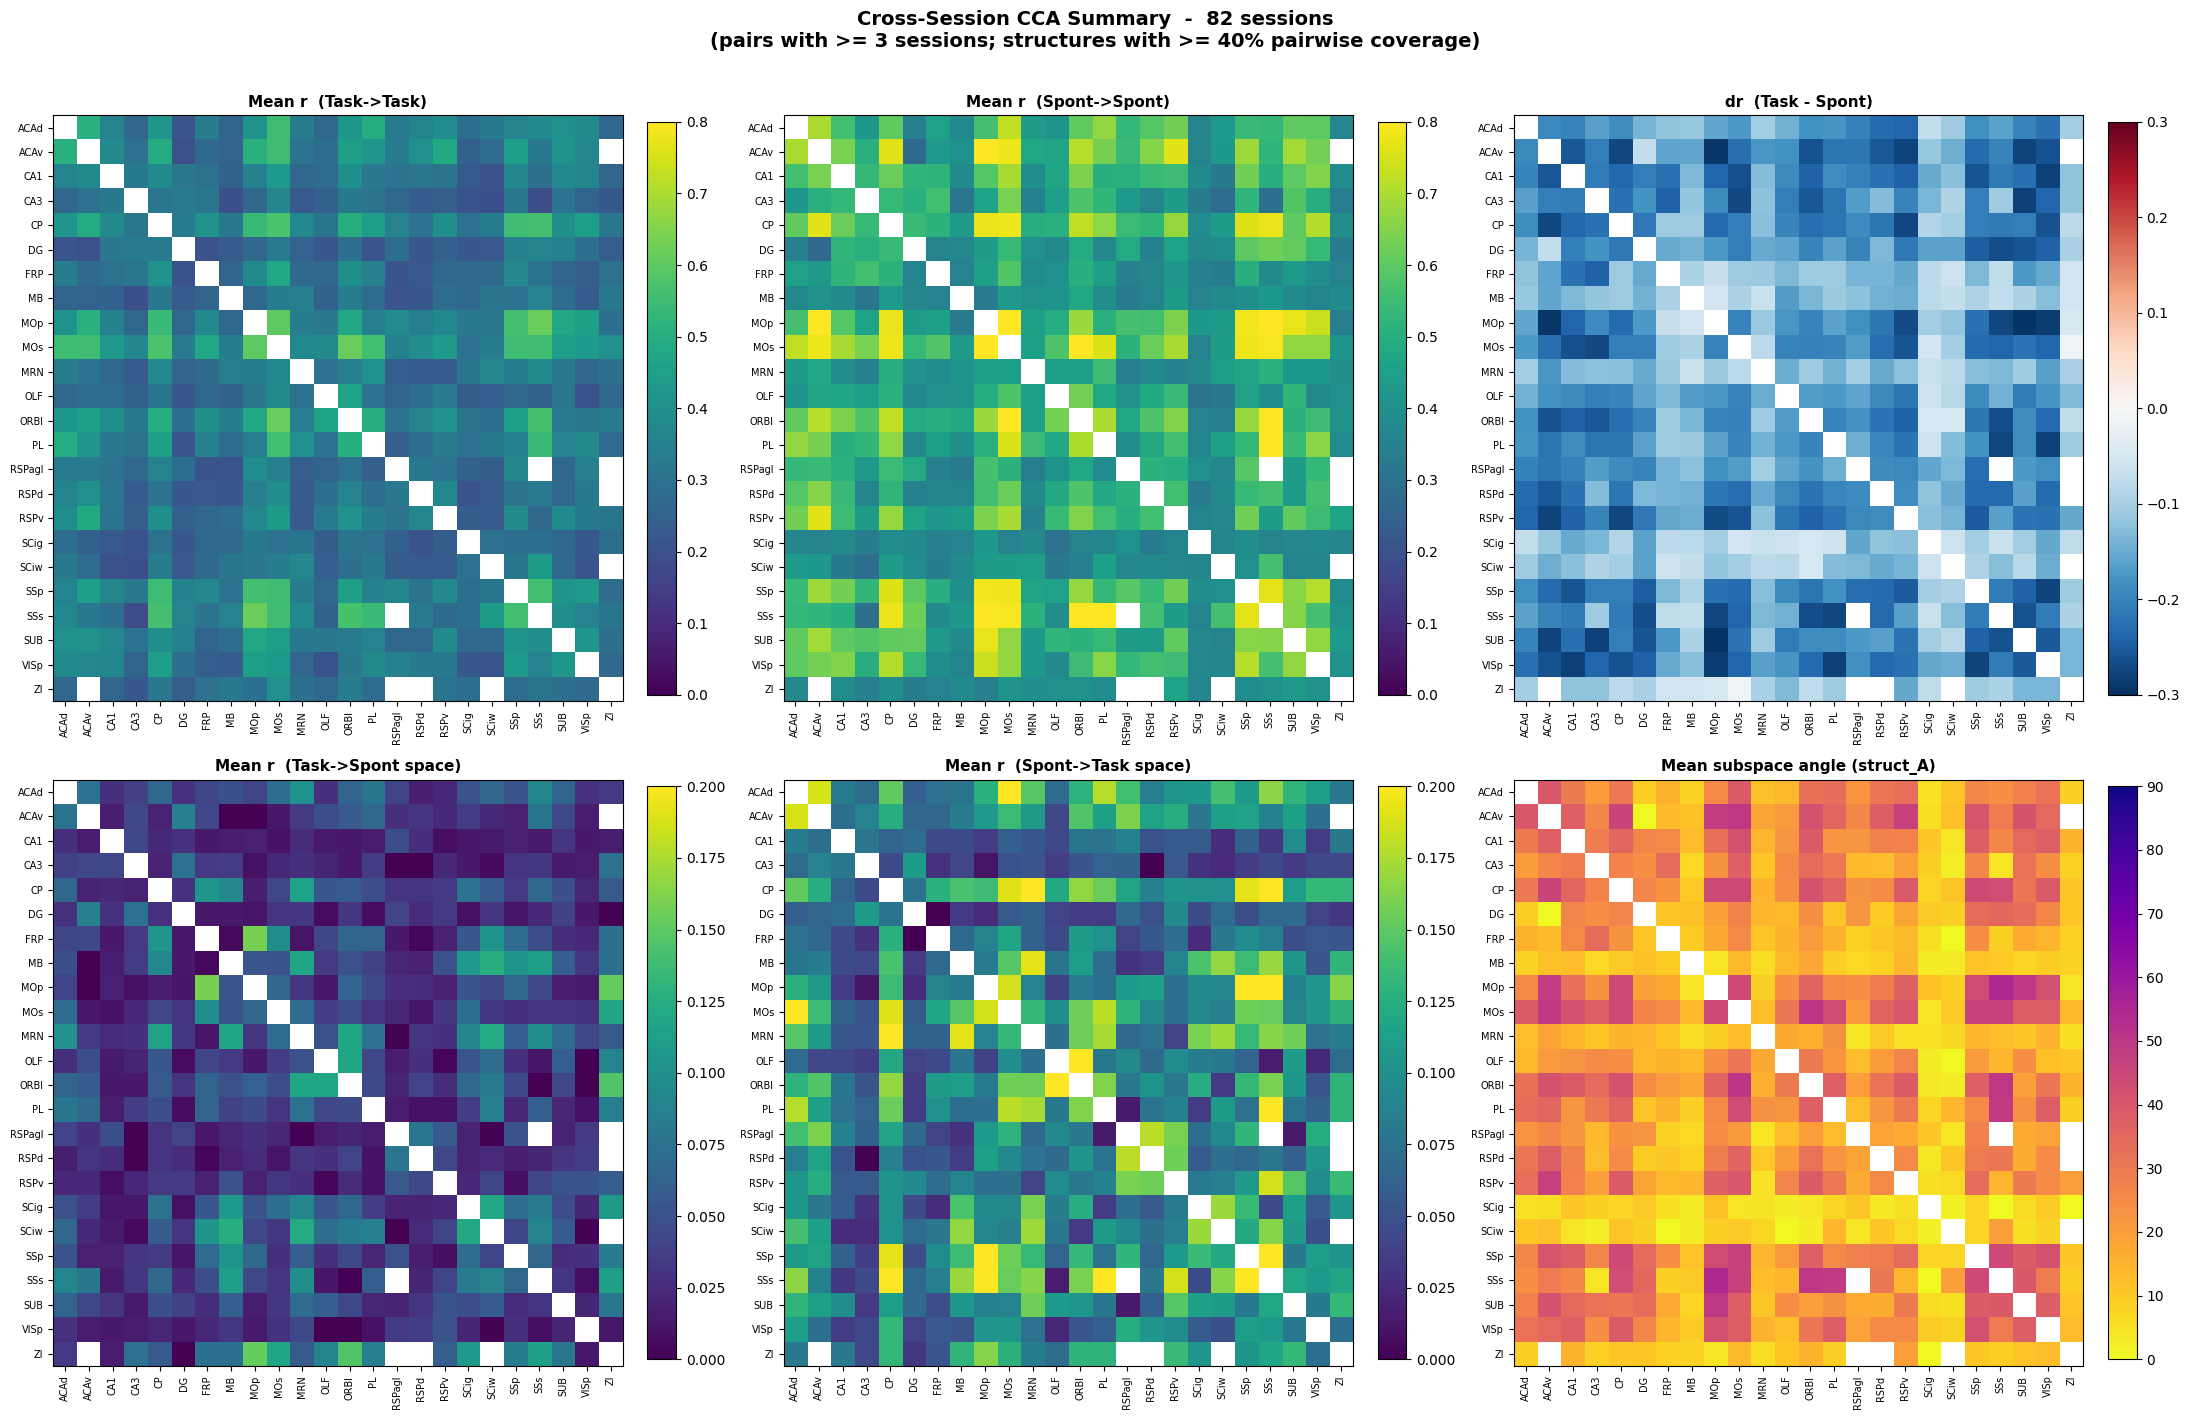

In [12]:
# ── Filter to well-covered structures ─────────────────────────────────────────
COVERAGE_THRESH = 0.40
plot_structs = filter_structs_by_coverage(
    cross_session_avg_filt, all_structs, COVERAGE_THRESH
)
print(f"Structures after coverage filter ({COVERAGE_THRESH:.0%}): "
      f"{len(plot_structs)} / {len(all_structs)}  ->  {plot_structs}")

# ── Build matrices ─────────────────────────────────────────────────────────────
mat_r_task     = build_matrix(cross_session_avg_filt, 'mean_r_task',          plot_structs)
mat_r_spont    = build_matrix(cross_session_avg_filt, 'mean_r_spont',         plot_structs)
mat_delta      = build_matrix(cross_session_avg_filt, 'delta_r_task_spont',   plot_structs)
mat_task_spont = build_matrix(cross_session_avg_filt, 'mean_r_task_in_spont', plot_structs)
mat_spont_task = build_matrix(cross_session_avg_filt, 'mean_r_spont_in_task', plot_structs)
mat_angle      = build_matrix(cross_session_avg_filt, 'mean_angle_A_deg',     plot_structs)
mat_n          = build_matrix(cross_session_avg_filt, 'n_sessions',           plot_structs)

n_sessions_total = all_summaries_df['session_id'].nunique()

# ── Main heatmap figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes = axes.flatten()

plot_heatmap(axes[0], mat_r_task,     plot_structs, 'Mean r  (Task->Task)',              0,    0.8,   'viridis',  fig)
plot_heatmap(axes[1], mat_r_spont,    plot_structs, 'Mean r  (Spont->Spont)',            0,    0.8,   'viridis',  fig)
plot_heatmap(axes[2], mat_delta,      plot_structs, 'dr  (Task - Spont)',               -0.3,  0.3,  'RdBu_r',   fig)
plot_heatmap(axes[3], mat_task_spont, plot_structs, 'Mean r  (Task->Spont space)',       0,    0.2,   'viridis',  fig)
plot_heatmap(axes[4], mat_spont_task, plot_structs, 'Mean r  (Spont->Task space)',       0,    0.2,   'viridis',  fig)
plot_heatmap(axes[5], mat_angle,      plot_structs, 'Mean subspace angle (struct_A)',    0,   90,    'plasma_r', fig)

plt.suptitle(
    f'Cross-Session CCA Summary  -  {n_sessions_total} sessions\n'
    f'(pairs with >= {MIN_SESSIONS} sessions; structures with >= {COVERAGE_THRESH:.0%} pairwise coverage)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram


def cluster_matrix(mat, n_clusters=2, linkage='average'):
    """
    Cluster a symmetric matrix using sklearn AgglomerativeClustering.
    Uses Fisher z-transform internally for correlation-valued matrices.
    """
    # Fill NaNs with row medians for clustering
    mat_filled = mat.copy()
    for i in range(mat.shape[0]):
        row_median = np.nanmedian(mat[i, :])
        mat_filled[i, np.isnan(mat[i, :])] = row_median if not np.isnan(row_median) else 0

    clustering = AgglomerativeClustering(
        n_clusters=n_clusters,
        metric='euclidean',
        linkage=linkage,
        compute_distances=True,
    )
    clustering.fit(mat_filled)

    # Build scipy-compatible linkage matrix from the sklearn model
    counts = np.zeros(clustering.children_.shape[0])
    n_samples = len(clustering.labels_)
    for i, merge in enumerate(clustering.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
    linkage_mat = np.column_stack(
        [clustering.children_, clustering.distances_, counts]
    ).astype(float)

    # Get leaf ordering from dendrogram
    dendro = dendrogram(linkage_mat, no_plot=True)
    order = np.array(dendro['leaves'])

    return order, linkage_mat, clustering.labels_


# Apply clustering to each matrix.
# For correlation matrices, apply Fisher z before clustering, then transform back.
corr_matrix_names = {'r_task', 'r_spont', 'delta', 'task_in_spont', 'spont_in_task'}

matrices = {
    'r_task': mat_r_task,
    'r_spont': mat_r_spont,
    'delta': mat_delta,
    'task_in_spont': mat_task_spont,
    'spont_in_task': mat_spont_task,
    'angle': mat_angle,
}

N_CLUSTERS = 2  # number of clusters for AgglomerativeClustering

clustering_results = {}
for name, mat in matrices.items():
    # Fisher z-transform correlation matrices before clustering
    if name in corr_matrix_names:
        mat_for_clustering = np.arctanh(np.clip(mat, -0.9999, 0.9999))
        # Preserve NaN positions
        mat_for_clustering[np.isnan(mat)] = np.nan
    else:
        mat_for_clustering = mat

    order, link_mat, labels = cluster_matrix(mat_for_clustering, n_clusters=N_CLUSTERS)
    clustering_results[name] = {
        'order': order,
        'linkage': link_mat,
        'clusters': labels,
        'ordered_structs': [plot_structs[i] for i in order],
    }
    print(f"{name}: {len(np.unique(labels))} clusters")

print(f"\nClustering complete (sklearn AgglomerativeClustering, n_clusters={N_CLUSTERS}).")

r_task: 2 clusters
r_spont: 2 clusters
delta: 2 clusters
task_in_spont: 2 clusters
spont_in_task: 2 clusters
angle: 2 clusters

Clustering complete (sklearn AgglomerativeClustering, n_clusters=2).


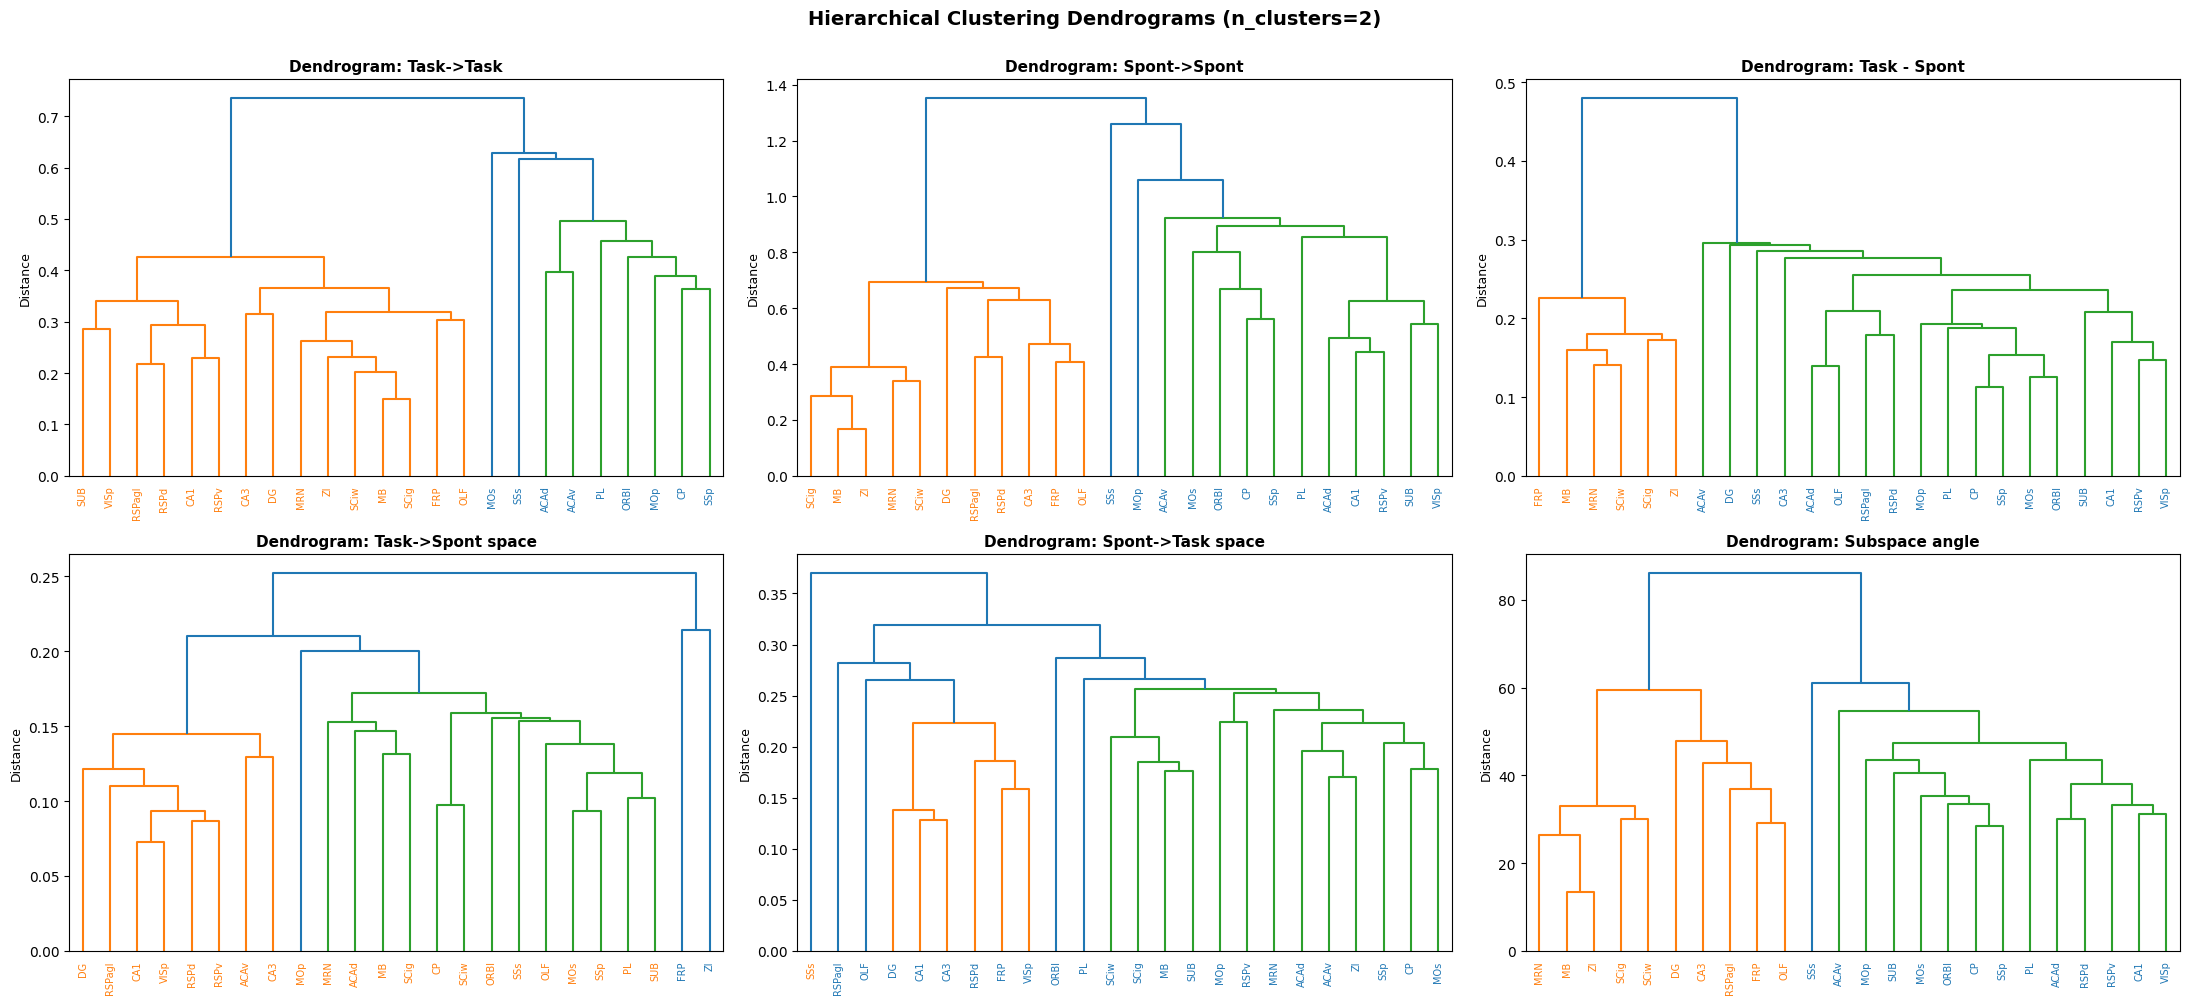

In [18]:
# Plot dendrograms for each clustering
fig_dendro, axes_dendro = plt.subplots(2, 3, figsize=(22, 10))
axes_dendro = axes_dendro.flatten()

titles = [
    'Task->Task',
    'Spont->Spont',
    'Task - Spont',
    'Task->Spont space',
    'Spont->Task space',
    'Subspace angle'
]

for idx, (name, title) in enumerate(zip(matrices.keys(), titles)):
    res = clustering_results[name]
    dendro_result = dendrogram(
        res['linkage'],
        ax=axes_dendro[idx],
        labels=np.array(plot_structs),
        leaf_rotation=90,
        leaf_font_size=7,
    )
    axes_dendro[idx].set_title(f'Dendrogram: {title}', fontsize=11, fontweight='bold')
    axes_dendro[idx].set_ylabel('Distance', fontsize=9)

    # Color-code cluster membership on tick labels
    cluster_colors = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green', 3: 'tab:red'}
    ordered_labels = res['clusters'][res['order']]
    for tick_idx, tick in enumerate(axes_dendro[idx].get_xticklabels()):
        clust_id = ordered_labels[tick_idx]
        tick.set_color(cluster_colors.get(clust_id, 'black'))

plt.suptitle(f'Hierarchical Clustering Dendrograms (n_clusters={N_CLUSTERS})',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

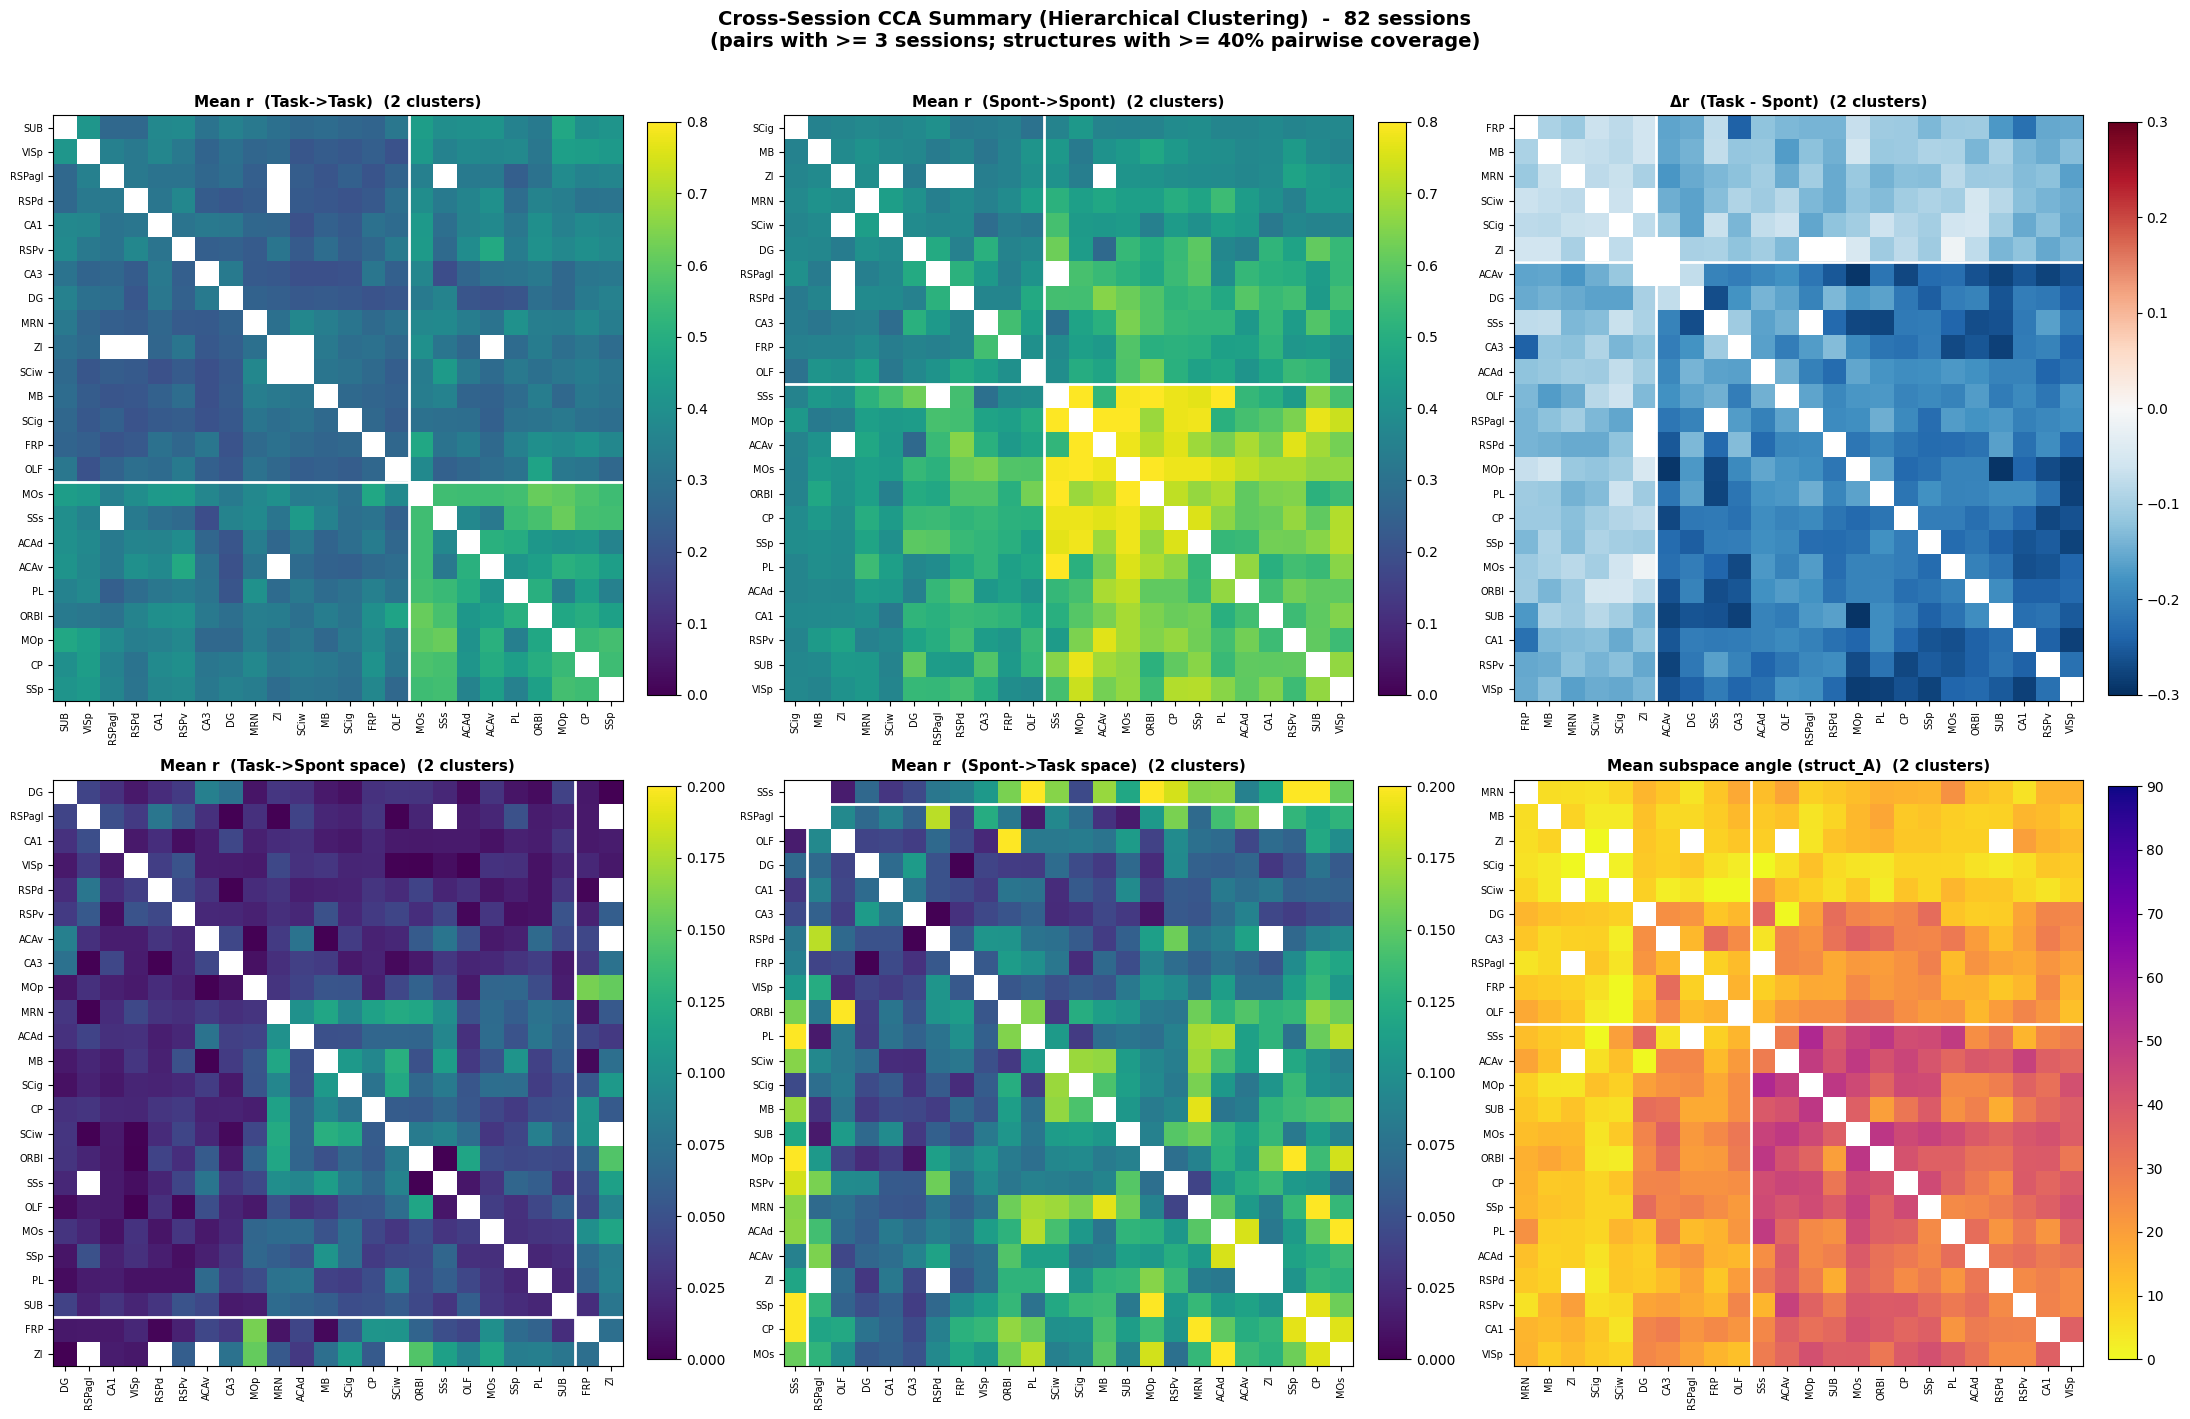


Clustered heatmaps plotted with cluster boundaries.


In [19]:
def plot_heatmap_clustered(ax, mat, structs, order, clusters, title, vmin, vmax, cmap, fig):
    """Plot heatmap with clustering order and cluster boundaries."""
    # Reorder matrix
    mat_ordered = mat[order][:, order]
    structs_ordered = [structs[i] for i in order]
    clusters_ordered = clusters[order]
    
    # Plot heatmap
    im = ax.imshow(mat_ordered, vmin=vmin, vmax=vmax, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(structs_ordered)))
    ax.set_yticks(range(len(structs_ordered)))
    ax.set_xticklabels(structs_ordered, rotation=90, fontsize=7)
    ax.set_yticklabels(structs_ordered, fontsize=7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    
    # Add cluster boundaries
    cluster_changes = np.where(np.diff(clusters_ordered) != 0)[0] + 0.5
    for pos in cluster_changes:
        ax.axhline(y=pos, color='white', linewidth=2, linestyle='-')
        ax.axvline(x=pos, color='white', linewidth=2, linestyle='-')
    
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    return mat_ordered, structs_ordered


# Plot clustered heatmaps
fig_clust, axes_clust = plt.subplots(2, 3, figsize=(22, 14))
axes_clust = axes_clust.flatten()

plot_configs = [
    ('r_task',         'Mean r  (Task->Task)',           0,    0.8,  'viridis'),
    ('r_spont',        'Mean r  (Spont->Spont)',         0,    0.8,  'viridis'),
    ('delta',          'Δr  (Task - Spont)',            -0.3,  0.3,  'RdBu_r'),
    ('task_in_spont',  'Mean r  (Task->Spont space)',    0,    0.2,  'viridis'),
    ('spont_in_task',  'Mean r  (Spont->Task space)',    0,    0.2,  'viridis'),
    ('angle',          'Mean subspace angle (struct_A)', 0,   90,    'plasma_r'),
]

ordered_matrices = {}
for idx, (mat_name, title, vmin, vmax, cmap) in enumerate(plot_configs):
    res = clustering_results[mat_name]
    mat_ordered, structs_ordered = plot_heatmap_clustered(
        axes_clust[idx],
        matrices[mat_name],
        plot_structs,
        res['order'],
        res['clusters'],
        f'{title}  ({len(np.unique(res["clusters"]))} clusters)',
        vmin, vmax, cmap, fig_clust
    )
    ordered_matrices[mat_name] = {
        'matrix': mat_ordered,
        'structs': structs_ordered,
        'clusters': res['clusters'][res['order']]
    }

plt.suptitle(
    f'Cross-Session CCA Summary (Hierarchical Clustering)  -  {n_sessions_total} sessions\n'
    f'(pairs with >= {MIN_SESSIONS} sessions; structures with >= {COVERAGE_THRESH:.0%} pairwise coverage)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

print("\nClustered heatmaps plotted with cluster boundaries.")

In [20]:
# Save clustering orderings to CSV for future reference
import csv

ordering_save_path = output_dir / 'cca_clustering_orderings.csv'

with open(ordering_save_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['clustering_type', 'position', 'structure', 'cluster_id'])
    
    for name, res in clustering_results.items():
        ordered_clusters = res['clusters'][res['order']]
        for pos, (struct, clust) in enumerate(zip(res['ordered_structs'], ordered_clusters)):
            writer.writerow([name, pos, struct, clust])

print(f"Clustering orderings saved to: {ordering_save_path}")

# Also save a summary
summary_save_path = output_dir / 'cca_clustering_summary.txt'

with open(summary_save_path, 'w') as f:
    f.write("CCA Cross-Session Clustering Summary\n")
    f.write("=" * 60 + "\n\n")
    
    for name, res in clustering_results.items():
        f.write(f"\n{name.upper()}\n")
        f.write("-" * 40 + "\n")
        f.write(f"Number of clusters: {len(np.unique(res['clusters']))}\n")
        f.write(f"Ordered structures:\n")
        
        ordered_clusters = res['clusters'][res['order']]
        current_cluster = ordered_clusters[0]
        f.write(f"  Cluster {current_cluster}: ")
        cluster_members = []
        
        for struct, clust in zip(res['ordered_structs'], ordered_clusters):
            if clust != current_cluster:
                f.write(", ".join(cluster_members) + "\n")
                current_cluster = clust
                f.write(f"  Cluster {current_cluster}: ")
                cluster_members = [struct]
            else:
                cluster_members.append(struct)
        
        f.write(", ".join(cluster_members) + "\n")

print(f"Clustering summary saved to: {summary_save_path}")

Clustering orderings saved to: \\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CCA results\cca_clustering_orderings.csv
Clustering summary saved to: \\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CCA results\cca_clustering_summary.txt
